In [25]:
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd

import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

import warnings
warnings.filterwarnings('ignore')

In [26]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [27]:
yys, yye= 2002, 2023
lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [28]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

In [29]:
DATA = xr.open_dataset(os.path.join(dir_base,'IMERG','3h','IMERG_Italy_3h_2001_01_01_2023_12_31.nc'))
DATA = DATA.sel(time=DATA.time.dt.year.isin(np.arange(yys,yye+1)))
lon2d_IM, lat2d_IM = np.meshgrid(DATA.lon.values, DATA.lat.values)
print(DATA.PRE.attrs['units'])

italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_IM, lat2d_IM)

IMERG_3h = DATA.PRE.where(mask_italy).values

DATA_1dy = (DATA/3).resample(time='1D').sum()
IMERG_1dy_accum = DATA_1dy.PRE.where(mask_italy).values

mm/day


In [30]:
DATA = xr.open_dataset(os.path.join(dir_base,'IMERG','1dy','IMERG_Italy_1dy_2000_06_01_2024_02_29.nc'))
DATA = DATA.sel(time=DATA.time.dt.year.isin(np.arange(yys,yye+1)))
print(DATA.PRE.attrs['units'])
IMERG_1dy = DATA.PRE.where(mask_italy).values

mm/day


In [31]:
SAT_cmap = plt.cm.Spectral_r

SAT_levels = np.arange(30, 250, 10)
SAT_norm = mcolors.BoundaryNorm(boundaries=SAT_levels, ncolors=SAT_cmap.N, extend='max')
SAT_norm = None

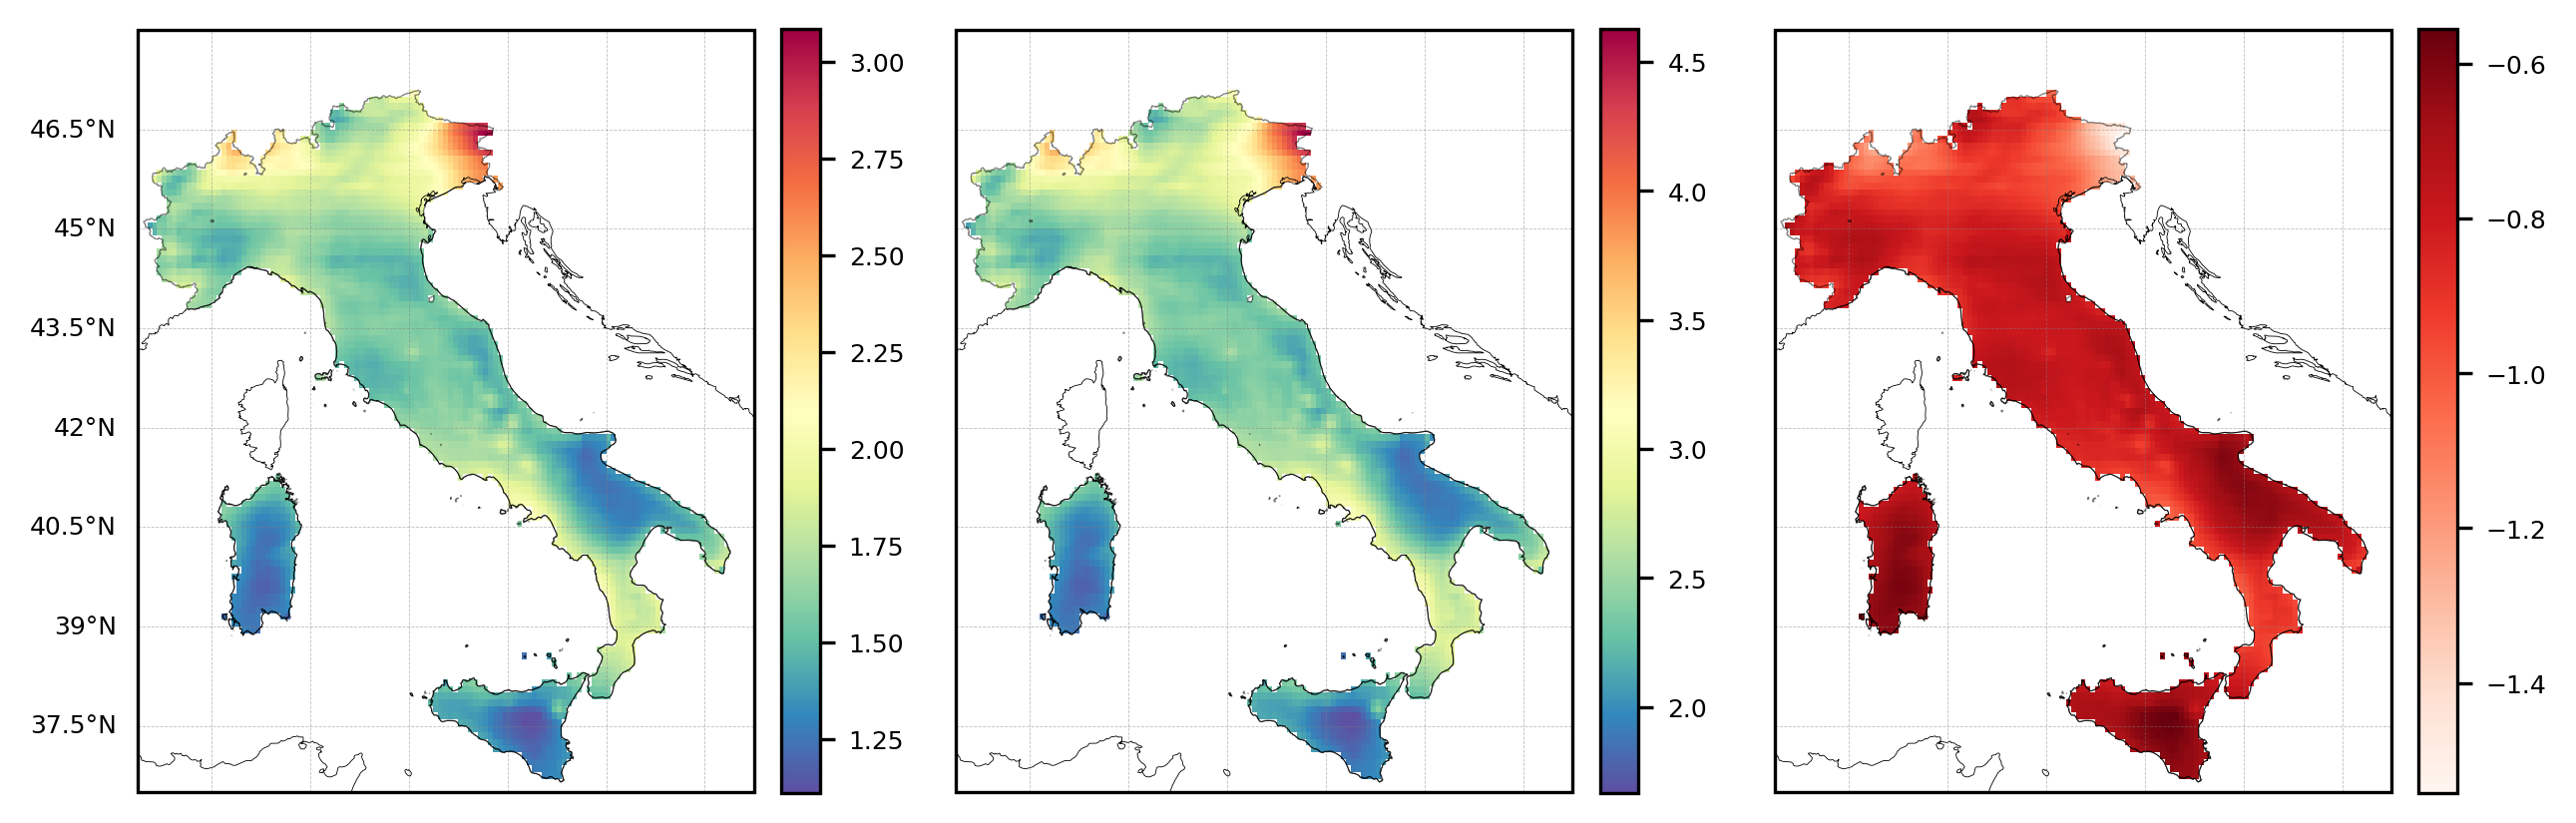

In [32]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10,4),dpi=300)
gs = gridspec.GridSpec(1,3)

axes = []
for nraw in range(1):
    for ncol in range(3):
        ax = fig.add_subplot(gs[nraw, ncol], projection=proj)
        ITALY.plot(facecolor='None', edgecolor='k', ax=ax, linewidth=0.3, zorder=21, alpha=0.5)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
        ax.coastlines(linewidth=0.2)
        axes.append(ax)

        gl = ax.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
        gl.top_labels = False
        if nraw == 1:
            gl.bottom_labels = True
        else:
            gl.bottom_labels = False
        gl.left_labels = False
        if ncol == 0:
            gl.left_labels = True
        gl.right_labels = False
        gl.xlabel_style = {'size': 6, 'color': 'k'}
        gl.ylabel_style = {'size': 6, 'color': 'k'}

a1 = axes[0].pcolormesh(lon2d_IM, lat2d_IM, np.nanmean(IMERG_1dy_accum, axis=0), cmap=SAT_cmap, norm=SAT_norm)
a2 = axes[1].pcolormesh(lon2d_IM, lat2d_IM, np.nanmean(IMERG_1dy, axis=0), cmap=SAT_cmap, norm=SAT_norm)
a3 = axes[2].pcolormesh(lon2d_IM, lat2d_IM, np.nanmean(IMERG_1dy_accum, axis=0) - np.nanmean(IMERG_1dy, axis=0), cmap='Reds')

cbar = plt.colorbar(a1, ax=axes[0], fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=6)
cbar = plt.colorbar(a2, ax=axes[1], fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=6)
cbar = plt.colorbar(a3, ax=axes[2], fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=6)

In [9]:
DATA = xr.open_dataset(os.path.join(dir_base,'GSMaP','3h','GSMaP_Italy_3h_2002_01_01_2024_12_31.nc'))
DATA = DATA.sel(time=DATA.time.dt.year.isin(np.arange(yys,yye+1)))
lon2d_GS, lat2d_GS = np.meshgrid(DATA.lon.values, DATA.lat.values)

italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_GS, lat2d_GS)

GSMaP_3h = DATA.PRE.where(mask_italy).values

In [10]:
DATA = xr.open_dataset(os.path.join(dir_base,'MSWEP','3h','MSWEP_Italy_3h_1980_01_01_2023_12_31.nc'))
DATA = DATA.sel(time=DATA.time.dt.year.isin(np.arange(yys,yye+1)))
lon2d_MS, lat2d_MS = np.meshgrid(DATA.lon.values, DATA.lat.values)

italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_MS, lat2d_MS)

MSWEP_3h = DATA.PRE.where(mask_italy).values

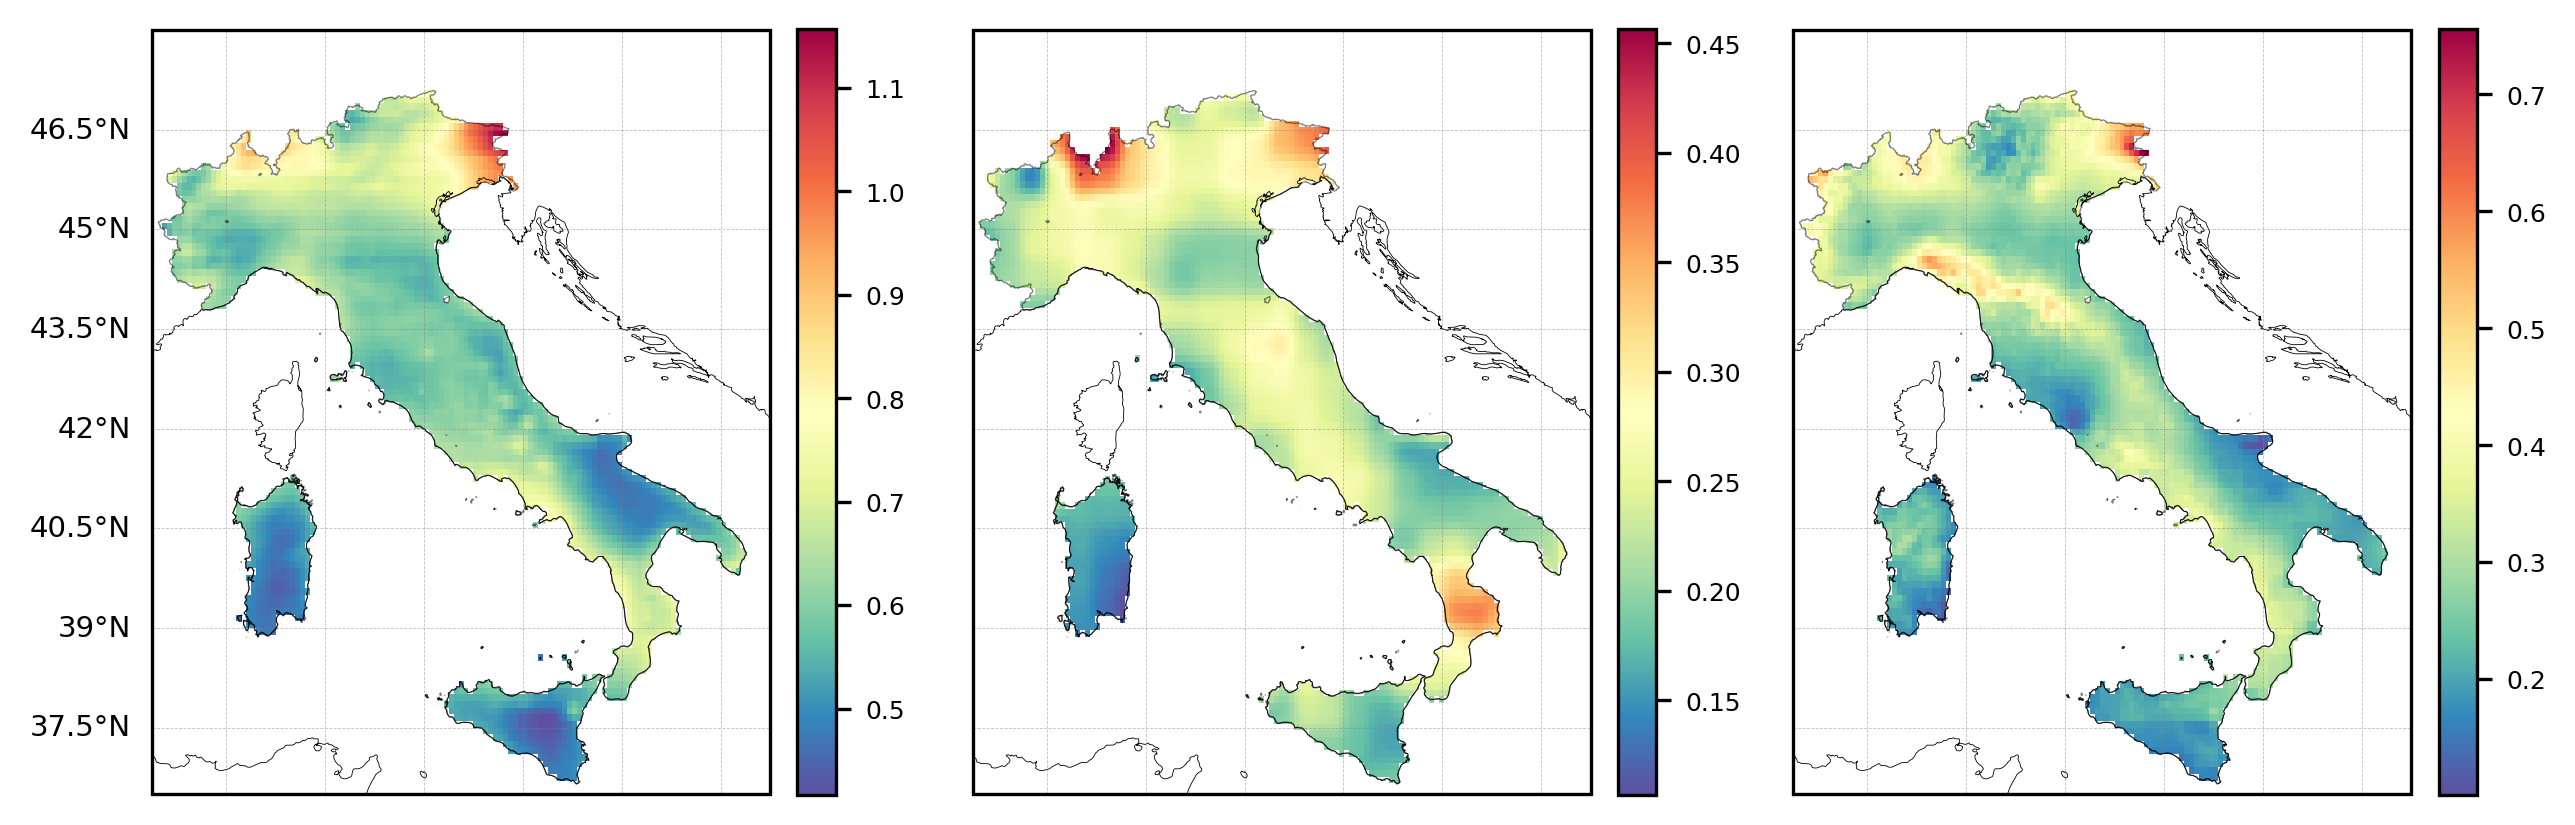

In [11]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10,4),dpi=300)
gs = gridspec.GridSpec(1,3)

axes = []
for nraw in range(1):
    for ncol in range(3):
        ax = fig.add_subplot(gs[nraw, ncol], projection=proj)
        ITALY.plot(facecolor='None', edgecolor='k', ax=ax, linewidth=0.3, zorder=21, alpha=0.5)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
        ax.coastlines(linewidth=0.2)
        axes.append(ax)

        gl = ax.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
        gl.top_labels = False
        if nraw == 1:
            gl.bottom_labels = True
        else:
            gl.bottom_labels = False
        gl.left_labels = False
        if ncol == 0:
            gl.left_labels = True
        gl.right_labels = False
        gl.xlabel_style = {'size': 7, 'color': 'k'}
        gl.ylabel_style = {'size': 7, 'color': 'k'}

a1 = axes[0].pcolormesh(lon2d_IM, lat2d_IM, np.nanmean(IMERG_3h, axis=0), cmap=SAT_cmap, norm=SAT_norm)
a2 = axes[1].pcolormesh(lon2d_GS, lat2d_GS, np.nanmean(GSMaP_3h, axis=0), cmap=SAT_cmap, norm=SAT_norm)
a3 = axes[2].pcolormesh(lon2d_MS, lat2d_MS, np.nanmean(MSWEP_3h, axis=0), cmap=SAT_cmap, norm=SAT_norm)

cbar = plt.colorbar(a1, ax=axes[0], fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=6)
cbar = plt.colorbar(a2, ax=axes[1], fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=6)
cbar = plt.colorbar(a3, ax=axes[2], fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=6)